In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")

## 1. Đọc dữ liệu và tiền xử lý

In [2]:
df = pd.read_csv(
    "laptop_price.csv",
    encoding='latin1'
)

# xử lý RAM
df['Ram'] = (
    df['Ram']
    .str.replace('GB', '')
    .astype(int)
)

# xử lý Weight
df['Weight'] = (
    df['Weight']
    .str.replace('kg', '')
    .astype(float)
)

print("Kích thước dữ liệu:", df.shape)

df.head()

Kích thước dữ liệu: (1303, 13)


,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,1339.69
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,898.94
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,575.00
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,2537.45
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,1803.60


## 2. Khám phá dữ liệu

In [3]:
print(df.info())

print("\nDữ liệu thiếu:")
print(df.isnull().sum())

display(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   laptop_ID         1303 non-null   int64  
 1   Company           1303 non-null   object 
 2   Product           1303 non-null   object 
 3   TypeName          1303 non-null   object 
 4   Inches            1303 non-null   float64
 5   ScreenResolution  1303 non-null   object 
 6   Cpu               1303 non-null   object 
 7   Ram               1303 non-null   int64  
 8   Memory            1303 non-null   object 
 9   Gpu               1303 non-null   object 
 10  OpSys             1303 non-null   object 
 11  Weight            1303 non-null   float64
 12  Price_euros       1303 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 132.5+ KB
None

Dữ liệu thiếu:
laptop_ID           0
Company             0
Product             0
TypeName            0
Inches         

,laptop_ID,Inches,Ram,Weight,Price_euros
count,1303.000000,1303.000000,1303.000000,1303.000000,1303.000000
mean,660.155794,15.017191,8.382195,2.038734,1123.686992
std,381.172104,1.426304,5.084665,0.665475,699.009043
min,1.000000,10.100000,2.000000,0.690000,174.000000
25%,331.500000,14.000000,4.000000,1.500000,599.000000
50%,659.000000,15.600000,8.000000,2.040000,977.000000
75%,990.500000,15.600000,8.000000,2.300000,1487.880000
max,1320.000000,18.400000,64.000000,4.700000,6099.000000


## Câu hỏi 1:
### Những yếu tố nào ảnh hưởng nhiều nhất đến giá laptop?

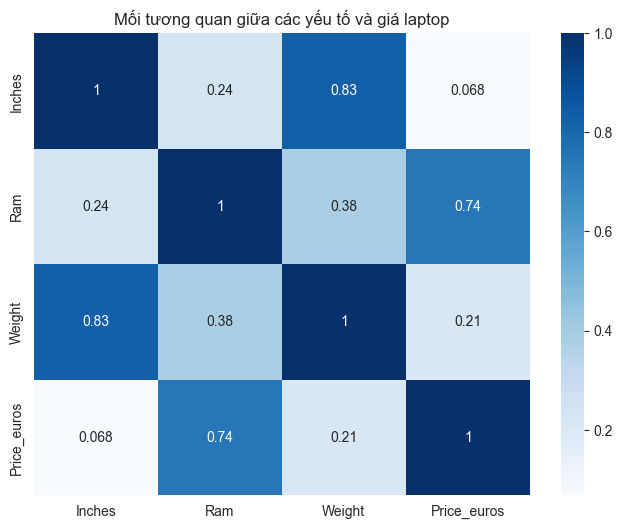

In [4]:
numeric_df = df[
    ['Inches',
     'Ram',
     'Weight',
     'Price_euros']
]

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='Blues'
)

plt.title(
    "Mối tương quan giữa các yếu tố và giá laptop"
)

plt.show()

## Câu hỏi 2:
### Hãng laptop nào có giá trung bình cao nhất và thấp nhất?

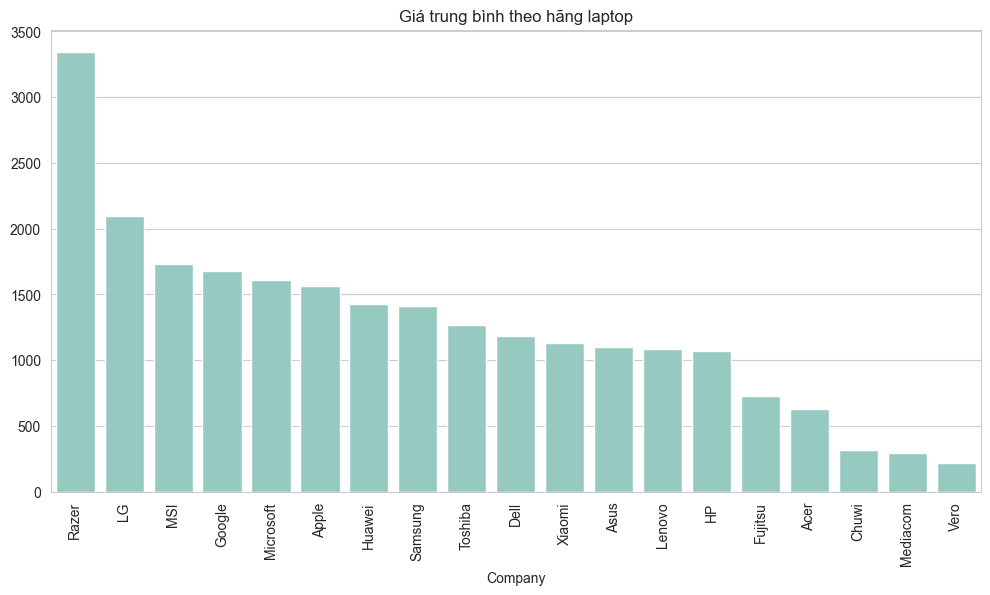

Company
Razer        3346.142857
LG           2099.000000
MSI          1728.908148
Google       1677.666667
Microsoft    1612.308333
Apple        1564.198571
Huawei       1424.000000
Samsung      1413.444444
Toshiba      1267.812500
Dell         1186.068990
Xiaomi       1133.462500
Asus         1104.169367
Lenovo       1086.384444
HP           1067.774854
Fujitsu       729.000000
Acer          626.775825
Chuwi         314.296667
Mediacom      295.000000
Vero          217.425000
Name: Price_euros, dtype: float64

In [5]:
brand_price = (
    df.groupby('Company')
    ['Price_euros']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=brand_price.index,
    y=brand_price.values
)

plt.xticks(rotation=90)

plt.title(
    "Giá trung bình theo hãng laptop"
)

plt.show()

brand_price

## Câu hỏi 3:
### Laptop gaming, ultrabook và notebook có sự chênh lệch giá như thế nào?

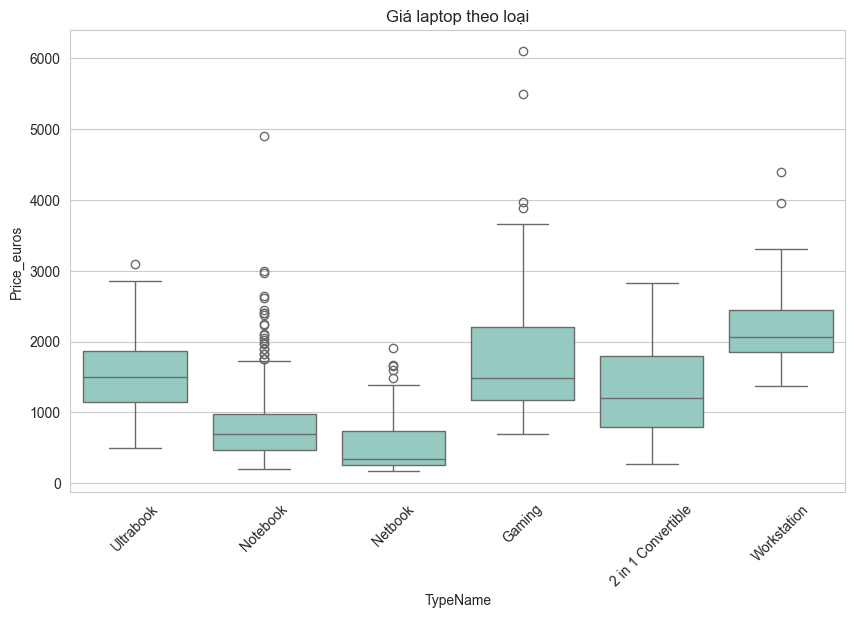

In [6]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x='TypeName',
    y='Price_euros',
    data=df
)

plt.xticks(rotation=45)

plt.title(
    "Giá laptop theo loại"
)

plt.show()

## Câu hỏi 4:
### Dung lượng RAM ảnh hưởng đến giá laptop ra sao?

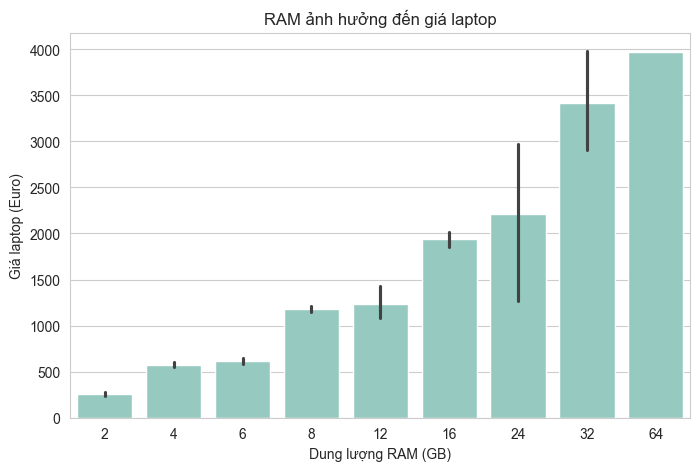

In [7]:
## Câu hỏi 4:
### Dung lượng RAM ảnh hưởng đến giá laptop ra sao?


plt.figure(figsize=(8, 5))

sns.barplot(
    x='Ram',
    y='Price_euros',
    data=df
)

plt.title(
    "RAM ảnh hưởng đến giá laptop"
)

plt.xlabel(
    "Dung lượng RAM (GB)"
)

plt.ylabel(
    "Giá laptop (Euro)"
)

plt.show()

Câu hỏi 5:
Môi quan hệ giữa cấu hình phần cứng và giá bán laptop

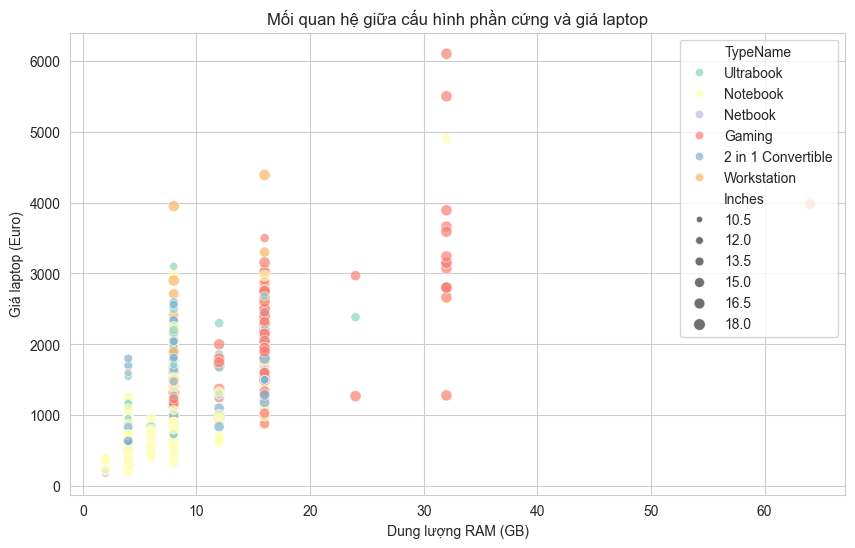

In [11]:
## Câu hỏi 5:
### Mối quan hệ giữa cấu hình phần cứng và giá bán laptop


plt.figure(figsize=(10, 6))

sns.scatterplot(
    x='Ram',
    y='Price_euros',
    hue='TypeName',
    size='Inches',
    data=df,
    alpha=0.7
)

plt.title(
    "Mối quan hệ giữa cấu hình phần cứng và giá laptop"
)

plt.xlabel(
    "Dung lượng RAM (GB)"
)

plt.ylabel(
    "Giá laptop (Euro)"
)

plt.show()

## Bài toán 1:
### Có thể dự đoán giá laptop dựa trên cấu hình phần cứng không?

KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH
Độ chính xác mô hình: 82.97%
Sai số trung bình (MAE): 173.44
Sai số RMSE: 294.07
Đánh giá: Mô hình dự đoán tốt


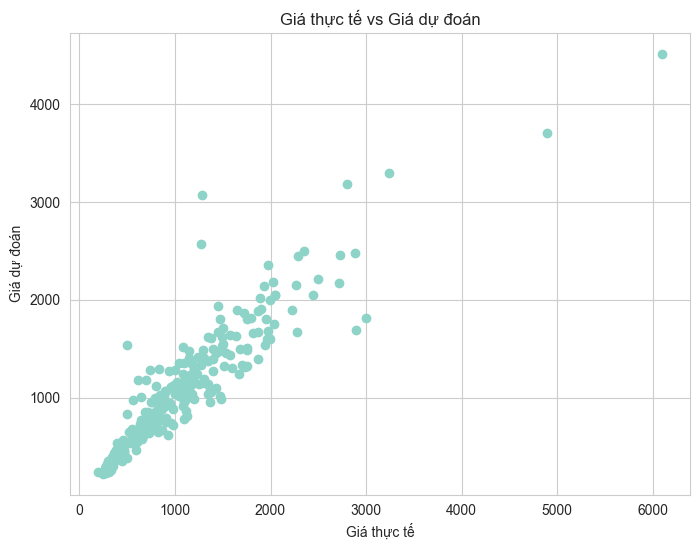

In [9]:
# ==========================
# DỰ ĐOÁN GIÁ LAPTOP
# (REGRESSION)
# ==========================

# Tạo bản sao dữ liệu
df_model = df.copy()

# ==========================
# 1. MÃ HÓA DỮ LIỆU
# ==========================

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

encoder = LabelEncoder()

categorical_cols = [
    'Company',
    'Product',
    'TypeName',
    'ScreenResolution',
    'Cpu',
    'Memory',
    'Gpu',
    'OpSys'
]

# Encode dữ liệu dạng chữ → số
for col in categorical_cols:
    df_model[col] = encoder.fit_transform(
        df_model[col]
    )

# ==========================
# 2. CHIA DỮ LIỆU
# ==========================

X = df_model.drop(
    'Price_euros',
    axis=1
)

y = df_model['Price_euros']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ==========================
# 3. XÂY DỰNG MÔ HÌNH
# ==========================

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(
    X_train,
    y_train
)

# ==========================
# 4. DỰ ĐOÁN GIÁ LAPTOP
# ==========================

y_pred = model.predict(
    X_test
)

# ==========================
# 5. ĐÁNH GIÁ MÔ HÌNH
# ==========================

mae = mean_absolute_error(
    y_test,
    y_pred
)
rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

r2 = r2_score(
    y_test,
    y_pred
)
accuracy = r2 * 100
print("=" * 40)
print("KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH")
print("=" * 40)
print(
    f"Độ chính xác mô hình: {accuracy:.2f}%"
)
print(
    f"Sai số trung bình (MAE): {mae:.2f}"
)
print(
    f"Sai số RMSE: {rmse:.2f}"
)

# Đánh giá mức độ mô hình
if accuracy >= 80:
    print("Đánh giá: Mô hình dự đoán tốt")
elif accuracy >= 60:
    print("Đánh giá: Mô hình dự đoán khá")
else:
    print("Đánh giá: Mô hình dự đoán chưa tốt")

# ==========================
# 6. BIỂU ĐỒ SO SÁNH
# ==========================

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred
)

plt.xlabel(
    "Giá thực tế"
)

plt.ylabel(
    "Giá dự đoán"
)

plt.title(
    "Giá thực tế vs Giá dự đoán"
)

plt.show()

## Bài toán 2:
### Có thể phân nhóm laptop thành các phân khúc không?

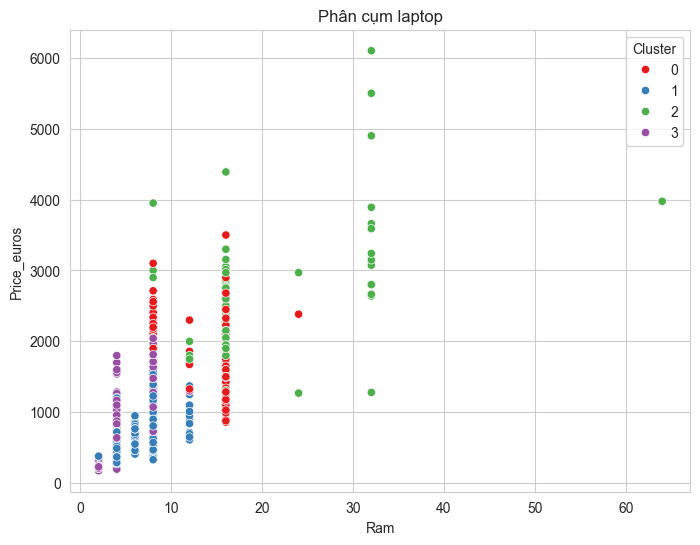

In [10]:
cluster_data = df_model[
    ['Ram',
     'Inches',
     'Weight',
     'Price_euros']
]

scaler = StandardScaler()

scaled_data = scaler.fit_transform(
    cluster_data
)

kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

df['Cluster'] = (
    kmeans.fit_predict(
        scaled_data
    )
)

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df['Ram'],
    y=df['Price_euros'],
    hue=df['Cluster'],
    palette='Set1'
)

plt.title(
    "Phân cụm laptop"
)

plt.show()